# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' regions of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain regions.


In [2]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [3]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [4]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world region of birth

In [5]:
csv_address='da_data/da3-birthYear-gender-region.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,1801-1810,22,Western Europe
3,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,1801-1810,22,Western Europe
4,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1802,female,Norwich,POINT (1.292778 52.628611),http://www.wikidata.org/entity/Q130191,1801-1810,24,Northern Europe


In [6]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      9544 non-null   object
 1   labelPer    9544 non-null   object
 2   birthYear   9544 non-null   int64 
 3   gender      9506 non-null   object
 4   labelPlace  9544 non-null   object
 5   geometry    9544 non-null   object
 6   uriPlace    9544 non-null   object
 7   periods     9544 non-null   object
 8   FID         9544 non-null   int64 
 9   REGION      9544 non-null   object
dtypes: int64(2), object(8)
memory usage: 745.8+ KB


## Distribution of regions of birth

In [7]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_region = df_p.groupby('REGION').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
REGION                       
Western Europe           2746
Eastern Europe           1781
Southern Europe          1278
Northern America         1003
South America             647
Northern Europe           486
Eastern Asia              464
European Russia           283
Western Asia              196
Southern Asia             151
Northern Africa           112
Central America           103
Asiatic Russia             53
Australia/New Zealand      47
Western Africa             43
Caribbean                  42
Southeastern Asia          34
Middle Africa              24
Southern Africa            20
Central Asia               19
Eastern Africa             12


In [8]:
### We define a function that codes and aggregates the values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeRegion(region: str):
    if ' Africa' in region:
        output='Africa'
    elif 'Russia' in region:
        output='Russia'
    elif 'Asia' in region:
        output='Asia'
    elif 'Austral' in region \
        or 'Polyn' in region \
        or 'Micron' in region:
        output='Australia/Ilands'
    elif 'Northern America' in region:
        output='America North'
    elif ' America' in region:
        output='America Central/South'
    elif 'Caribb' in region:
        output='America Central/South'
    else:
        output=region
    return output                   

In [9]:
### Test the function
# r='Southern Africa'
# r='Central Asia'
r='Asiatic Russia'
codeRegion(r)

'Russia'

In [10]:
### Create a new column with the coded values
df_p['coded_region']=df_p.REGION.apply(lambda x : codeRegion(x))

In [11]:
### Group and count
df_region = df_p.groupby('coded_region').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
coded_region                 
Western Europe           2746
Eastern Europe           1781
Southern Europe          1278
America North            1003
Asia                      864
America Central/South     792
Northern Europe           486
Russia                    336
Africa                    211
Australia/Ilands           47


In [12]:
### Add frequencies to the counts aof a variable's categories

df_region['frequency'] = (100 * df_region['number'] \
                                   / df_region['number'].sum()).round(2)
df_region



,number,frequency
coded_region,,
Western Europe,2746,28.77
Eastern Europe,1781,18.66
Southern Europe,1278,13.39
America North,1003,10.51
Asia,864,9.05
America Central/South,792,8.30
Northern Europe,486,5.09
Russia,336,3.52
Africa,211,2.21


In [13]:
### Transform to one row dataframe
ljt = pd.DataFrame(df_region['frequency'].sort_values(ascending=False)).T
ljt

coded_region,Western Europe,Eastern Europe,Southern Europe,America North,Asia,America Central/South,Northern Europe,Russia,Africa,Australia/Ilands
frequency,28.77,18.66,13.39,10.51,9.05,8.3,5.09,3.52,2.21,0.49


In [14]:
### Create color palette
colors = plt.cm.tab20(range(10))
print(colors[:2], '\n', colors[-2:])

[[0.12156863 0.46666667 0.70588235 1.        ]
 [0.68235294 0.78039216 0.90980392 1.        ]] 
 [[0.58039216 0.40392157 0.74117647 1.        ]
 [0.77254902 0.69019608 0.83529412 1.        ]]


In [15]:
### Reverse the list
rev_col=colors[::-1]
print(rev_col[:2], '\n', rev_col[-2:])

[[0.77254902 0.69019608 0.83529412 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]] 
 [[0.68235294 0.78039216 0.90980392 1.        ]
 [0.12156863 0.46666667 0.70588235 1.        ]]


[]

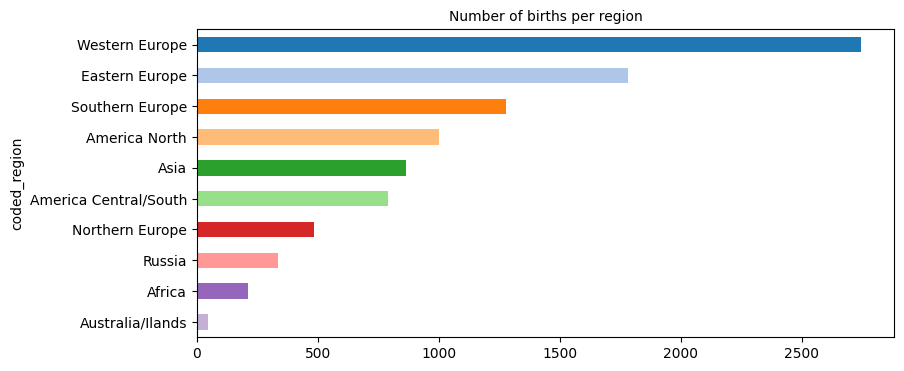

In [16]:
## Distribution of births per region
fig = df_region.number.sort_values().plot(kind='barh', figsize=(9,4), color=rev_col, width=0.5)
fig.set_title('Number of births per region', size=10)
plt.plot()

[]

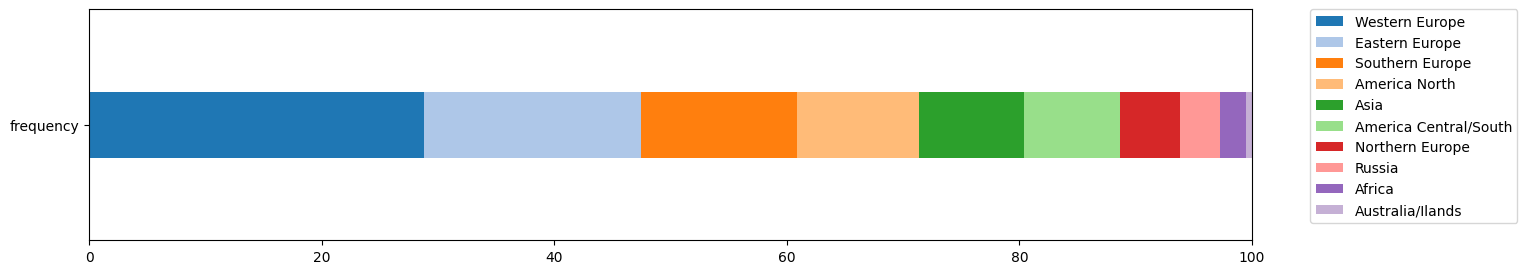

In [17]:
### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

### Transform birth years to periods of activity years

In [18]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [19]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+4, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1846, 1871, 1896, 1921, 1946] [1921, 1946, 1971, 1996, 2021] 7


In [20]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_p['per_25'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America,America North,1851,1846-1870
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe,Western Europe,1855,1846-1870
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,1801-1810,22,Western Europe,Western Europe,1846,1846-1870


In [21]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_p.groupby(by='per_25').size())
activities_per.columns=['number']
print(activities_per)

           number
per_25           
1846-1870      39
1871-1895     112
1896-1920     316
1921-1945     535
1946-1970    1169
1971-1995    3864
1996-2020    3060


In [22]:
### Add frequency

activities_per['frequency'] = (100 * activities_per['number'] \
                                   / activities_per['number'].sum()).round(2)
activities_per


,number,frequency
per_25,,
1846-1870,39,0.43
1871-1895,112,1.23
1896-1920,316,3.47
1921-1945,535,5.88
1946-1970,1169,12.85
1971-1995,3864,42.48
1996-2020,3060,33.64


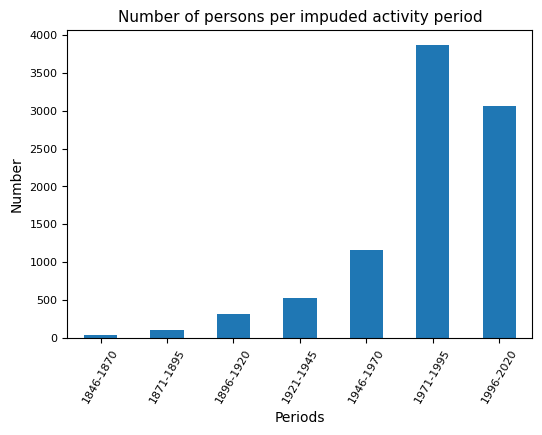

In [23]:
### Distribution by impuded active generations
ax = activities_per.number.plot(kind='bar',rot=60, fontsize=8, figsize=(6,4))
plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Number of persons per impuded activity period', size=11)
plt.show()

In [24]:
### Transform to a one row dataframe
ljt = pd.DataFrame(activities_per.frequency.sort_index(ascending=True)).T
ljt

per_25,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020
frequency,0.43,1.23,3.47,5.88,12.85,42.48,33.64


In [25]:
### Map the intensity of the colours to the frequency

frequencies = activities_per.frequency.sort_index(ascending=True)

# Normalize frequencies to 0-1 range for colormap mapping
norm = mcolors.Normalize(vmin=frequencies.min(), vmax=frequencies.max())

# Create a list of colors based on the 'Blues' colormap
# Higher frequencies get darker blues
colors = [plt.cm.Blues(norm(freq)) for freq in frequencies]

[]

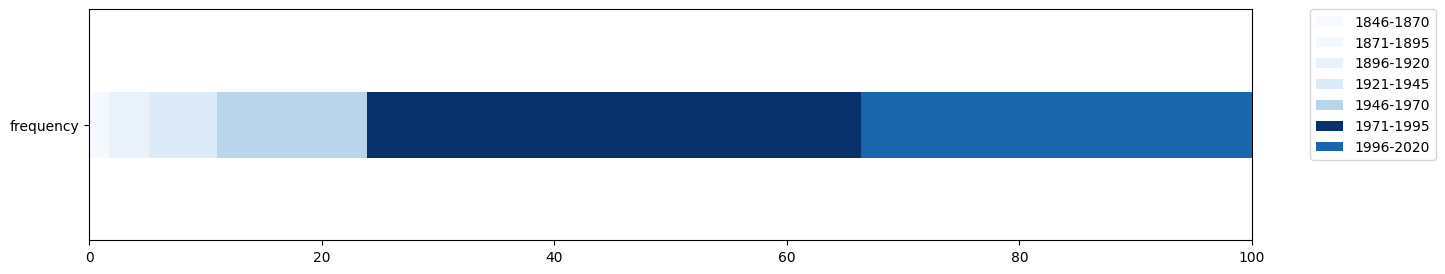

In [26]:
### Frequencies of periods. Total = 100%

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

## Bivariate analysis

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [27]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_region=pd.crosstab(df_p.per_25, df_p.coded_region, margins=True)
per_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_25,,,,,,,,,,,
1846-1870,0,0,2,0,0,4,6,5,2,20,39
1871-1895,0,8,6,1,0,17,8,12,19,41,112
1896-1920,2,22,62,7,0,67,19,5,45,87,316
1921-1945,1,23,91,40,3,134,20,17,40,166,535
1946-1970,17,69,241,87,2,276,61,28,75,313,1169
1971-1995,117,355,432,341,16,646,230,151,473,1103,3864
1996-2020,67,291,160,357,25,503,131,104,537,885,3060
All,204,768,994,833,46,1647,475,322,1191,2615,9095


In [28]:
### If needed, you could restrict to a minimal count and having thus 
# all the periods but with less regions
X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X_reg_all_period

coded_region,America Central/South,America North,Asia,Eastern Europe,Southern Europe,Western Europe
per_25,,,,,,
1846-1870,0,2,0,4,2,20
1871-1895,8,6,1,17,19,41
1896-1920,22,62,7,67,45,87
1921-1945,23,91,40,134,40,166
1946-1970,69,241,87,276,75,313
1971-1995,355,432,341,646,473,1103
1996-2020,291,160,357,503,537,885


In [29]:
### But we keep here all the information
X_reg_all_period = per_vs_region.iloc[:-1, :-1 ]
X_reg_all_period

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1846-1870,0,0,2,0,0,4,6,5,2,20
1871-1895,0,8,6,1,0,17,8,12,19,41
1896-1920,2,22,62,7,0,67,19,5,45,87
1921-1945,1,23,91,40,3,134,20,17,40,166
1946-1970,17,69,241,87,2,276,61,28,75,313
1971-1995,117,355,432,341,16,646,230,151,473,1103
1996-2020,67,291,160,357,25,503,131,104,537,885


## Chi-square Test of Independence of Categorical Variables

Key distinction:
* Observed Table: Your actual count data. Can contain zeros or small numbers without invalidating the test immediately.
* Expected Table: Calculated values based on row/column totals

$$ E = \frac{\text{row total} \times \text{column total}}{\text{grand total}} $$

* Chi-square :

$$ \chi^2 = \sum_{i=1}^{n} \frac{(O_i - E_i)^2}{E_i} $$

* More about this topic in [Chi-Square Test of Independence: Definition, Formula, and Example](https://www.statology.org/chi-square-test-of-independence/)
* See the whole website: https://www.statology.org/tutorials/


In [30]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(X_reg_all_period)


In [31]:
### Expected values under independent sampling (H0 hypotheses)

## For the chi-square test the min value in each cell of the expected values should be 5

dfe = pd.DataFrame(expected).round(1)
dfe.index = X_reg_all_period.index
dfe.columns = X_reg_all_period.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1846-1870,0.9,3.3,4.3,3.6,0.2,7.1,2.0,1.4,5.1,11.2
1871-1895,2.5,9.5,12.2,10.3,0.6,20.3,5.8,4.0,14.7,32.2
1896-1920,7.1,26.7,34.5,28.9,1.6,57.2,16.5,11.2,41.4,90.9
1921-1945,12.0,45.2,58.5,49.0,2.7,96.9,27.9,18.9,70.1,153.8
1946-1970,26.2,98.7,127.8,107.1,5.9,211.7,61.1,41.4,153.1,336.1
1971-1995,86.7,326.3,422.3,353.9,19.5,699.7,201.8,136.8,506.0,1111.0
1996-2020,68.6,258.4,334.4,280.3,15.5,554.1,159.8,108.3,400.7,879.8


In [32]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 54 ; Chi-square value: 583.24


### Probability distribution of Chi-square values in relation to degrees of freedom

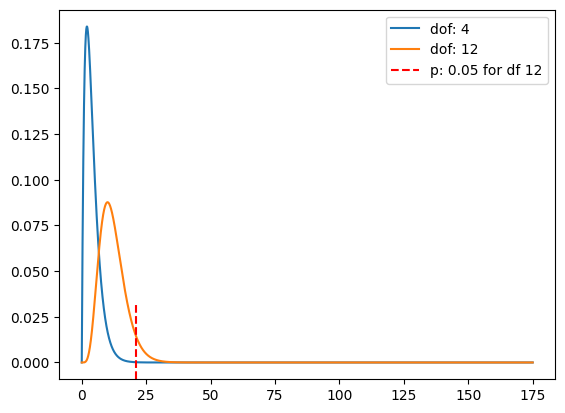

In [33]:
### Documentation ! 
## https://www.statology.org/plot-chi-square-distribution-python/
# x-axis ranges from 0 to 1750 with .001 steps
x = np.arange(0, 175, 0.001)

### plot Chi-square distribution with 4 degrees of freedom
# cf. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
plt.plot(x, stats.chi2.pdf(x, df=4), label='dof: 4')
plt.plot(x, stats.chi2.pdf(x, df=12), label='dof: 12')

plt.axvline(x=21.026, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df 12')

plt.legend()
plt.show()

### Statistical test: rejection of the null hypothesis of independence?

The null hypothesis H0 is that the variables are independent

* e.g. the critical Chi-square value for 12 degrees of freedom, at the 5% level (= 0.05) is 21.026
  * [Chi-square Distribution Table](https://www.statology.org/chi-square-distribution-table/) (Zach Bobbitt)
  * [Chi-squared distribution](https://en.wikipedia.org/wiki/Chi-squared_distribution) (Wikipedia)

* If the chi-square value is above the critical value at a 5% error rate, H0 (the null hypothesis of independence) can be rejected with an error probability under 0.05 (5%). 
* We can then measure the strength of the relationship and its components, including using Cramer’s coefficient

In [34]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 54 ; Chi-square value: 583.24


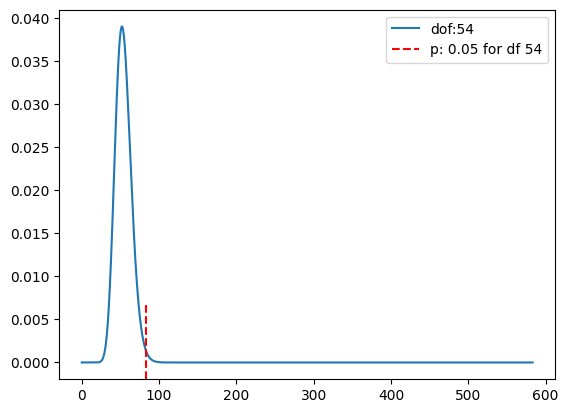

In [35]:
### Applied to our case
x = np.arange(0, statistic, 0.001)

### plot Chi-square distribution with 63 degrees of freedom
plt.plot(x, stats.chi2.pdf(x, df=dof), label='dof:'+ str(dof) )

plt.axvline(x=82.529, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df ' + str(dof))

plt.legend()
plt.show()

In [36]:
### P-value
print('p-value :', p)

p-value : 7.43399713653589e-90


### Caveats regarding the expected values table

The Chi-square test relies on a mathematical approximation that assumes the expected distribution is smooth. If the expected count in a cell is too low, the approximation breaks down, even if your actual observed data has high numbers elsewhere.

This is where the "no value < 1" and "max 20% < 5" rules must be checked.

The standard rule of thumb tehrefore states:

* No cell should have an expected frequency less than 1.
* No more than 20% of the cells should have an expected frequency less than 5.

If your table violates these conditions (e.g., many cells < 5 or any cell < 1), the Chi-square approximation may be inaccurate.

### Cramér's V (Cramér's phi coefficient)

* We calculate Cramér's V to measure the strength of the association between the two categorical variables.
* Interpretation of values:
  * 0.0-0.1: neglibigle;
  * 0.1-0.3: weak;
  * 0.3-0.5: moderate;
  * &gt; 0.5: strong

$$ 
V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}} 
$$

* ${\chi^2}$ = 'statistic' in Python *stats* library
* n = number of individuals
* k = normalization Factor (kk):
  * Formula: k=min⁡(r−1,c−1)k (Minimum)
  * Usage: Used only in the denominator of Cramér's V to normalize the score between 0 and 1.



In [37]:
## Cramer's V with all calculation steps to demonstrate normalization

# 1. Total sample size (n)
n = per_vs_region.iloc[-1, -1]
# print(n)

# 2. Get the dimensions of the table
r, c = X_reg_all_period.shape

# 3. Calculate the correct denominator: min(rows-1, columns-1)
# Note: The returned ‘dof’ is (r-1)*(c-1); this is not directly the divisor for Cramer's rule
k = min(r - 1, c - 1)
# print(k)

# Avoid dividing by zero if the table is 1x1
if k == 0:
    cramers_v = 0
else:
    # 4. Apply the formula
    cramers_v = np.sqrt(statistic / (n * k))

print(f"Cramer's V : {cramers_v.round(5)}")

Cramer's V : 0.10338


In [38]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X_reg_all_period, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10338234778131775


In [39]:
# 2. Calculate Adjusted Residuals
observed = X_reg_all_period
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
print(row_totals)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
print(col_totals)
n = observed.sum().sum()

[[  39]
 [ 112]
 [ 316]
 [ 535]
 [1169]
 [3864]
 [3060]]
[[ 204  768  994  833   46 1647  475  322 1191 2615]]


In [40]:
# Basic formula
residuals = (round((observed-expected)/np.sqrt(expected),2))
residuals.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1846-1870,-0.9,-1.8,-1.1,-1.9,-0.4,-1.2,2.8,3.1,-1.4,2.6
1871-1895,-1.6,-0.5,-1.8,-2.9,-0.8,-0.7,0.9,4.0,1.1,1.6
1896-1920,-1.9,-0.9,4.7,-4.1,-1.3,1.3,0.6,-1.8,0.6,-0.4
1921-1945,-3.2,-3.3,4.2,-1.3,0.2,3.8,-1.5,-0.4,-3.6,1.0
1946-1970,-1.8,-3.0,10.0,-1.9,-1.6,4.4,-0.0,-2.1,-6.3,-1.3
1971-1995,3.3,1.6,0.5,-0.7,-0.8,-2.0,2.0,1.2,-1.5,-0.2
1996-2020,-0.2,2.0,-9.5,4.6,2.4,-2.2,-2.3,-0.4,6.8,0.2


In [41]:
# Formula for Adjusted Residuals
adjusted_resids = (observed - expected) / np.sqrt(expected * (1 - row_totals/n) * (1 - col_totals/n))
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1846-1870,-0.9,-1.9,-1.2,-2.0,-0.4,-1.3,2.9,3.1,-1.5,3.1
1871-1895,-1.6,-0.5,-1.9,-3.1,-0.8,-0.8,0.9,4.1,1.2,1.8
1896-1920,-2.0,-1.0,5.0,-4.4,-1.3,1.5,0.6,-1.9,0.6,-0.5
1921-1945,-3.3,-3.6,4.6,-1.4,0.2,4.3,-1.6,-0.5,-4.0,1.2
1946-1970,-2.0,-3.3,11.4,-2.2,-1.7,5.2,-0.0,-2.3,-7.3,-1.6
1971-1995,4.3,2.2,0.7,-0.9,-1.1,-3.0,2.7,1.6,-2.1,-0.4
1996-2020,-0.2,2.6,-12.4,5.9,3.0,-2.9,-2.9,-0.5,9.0,0.3


In [42]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(X_reg_all_period)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1846-1870,-0.4,-1.7,-1.2,-1.8,0.6,-1.4,2.7,3.0,-1.6,2.8
1871-1895,-1.3,-0.5,-1.9,-3.1,-0.1,-0.8,0.9,4.1,1.2,1.8
1896-1920,-2.0,-1.0,5.0,-4.4,-0.9,1.4,0.6,-1.9,0.6,-0.5
1921-1945,-3.3,-3.6,4.7,-1.4,0.1,4.3,-1.6,-0.5,-4.0,1.2
1946-1970,-2.0,-3.4,11.4,-2.2,-1.8,5.2,-0.0,-2.3,-7.2,-1.6
1971-1995,4.3,2.2,0.7,-1.0,-1.2,-2.9,2.7,1.6,-2.1,-0.4
1996-2020,-0.3,2.6,-12.4,5.9,2.8,-2.9,-2.9,-0.5,9.0,0.3


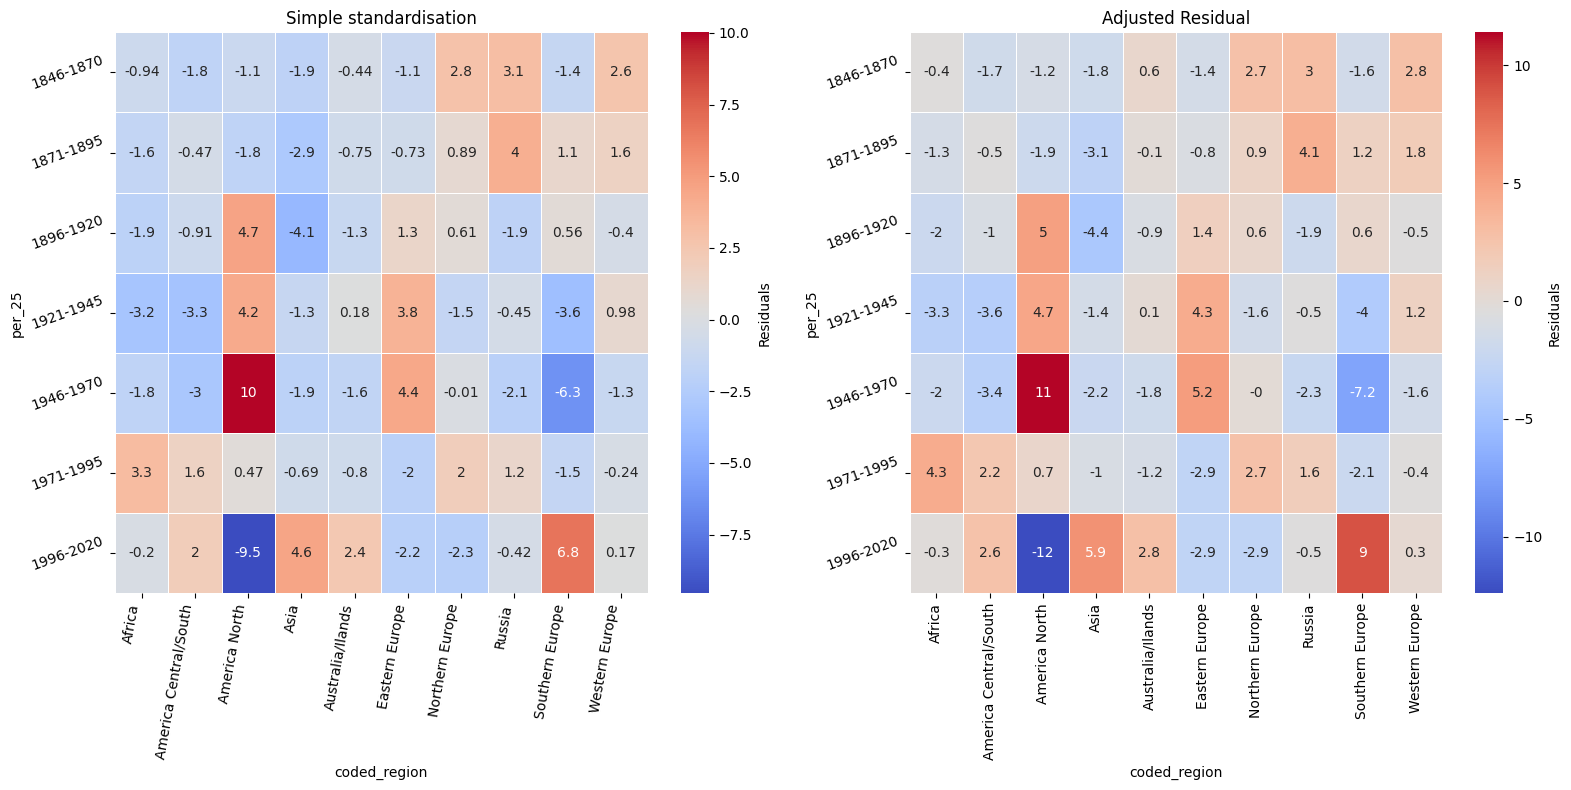

In [43]:
### Compare the two methods of calculation of residuals

# 3. Plot
fig, ax = plt.subplots(1,2,figsize=(16,8))         

# Create heatmap
sns.heatmap(
    residuals, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[0],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80, ha='right')
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=20, va='center')
ax[0].set_title("Simple standardisation", fontsize=12)


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[1],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
#ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=20, va='center')
ax[1].set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

Comment : 
* in this case, the differences resulting from standardization are minimal
* in both heatmaps we can easily observe the main differences from the situation of statistical independence and the evolution in time of the number of active astronomres/physicists per region

## Bivariate analysis genders

In [44]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]

In [45]:
gender_vs_region=pd.crosstab(df_pg.gender, df_pg.coded_region, margins=True)
gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
gender,,,,,,,,,,,
female,54,274,216,166,15,400,125,68,310,587,2215
male,157,516,782,675,27,1381,360,266,962,2155,7281
All,211,790,998,841,42,1781,485,334,1272,2742,9496


In [46]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_region.iloc[:-1, :-1 ]

In [47]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [48]:
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
gender,,,,,,,,,,
female,49.2,184.3,232.8,196.2,9.8,415.4,113.1,77.9,296.7,639.6
male,161.8,605.7,765.2,644.8,32.2,1365.6,371.9,256.1,975.3,2102.4


In [49]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 79.25519973578689 , dof : 9
p-value : 2.2717478009227085e-13


In [50]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.09135735755401993


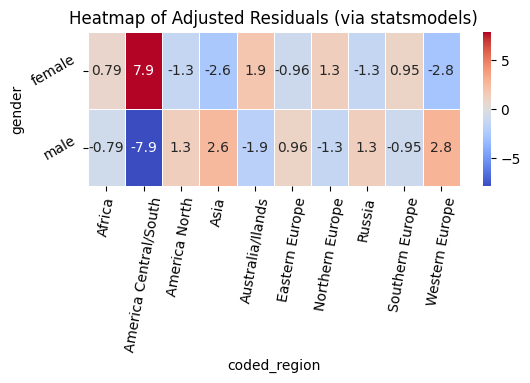

In [51]:
import statsmodels.api as sm

# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(6,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some regions. The difference is statistically relevant although weak: Cramer's V = 0.1

## Bivariate analysis genders+generations vs regions

In [52]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America,America North,1851,1846-1870
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe,Western Europe,1855,1846-1870


In [53]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [57]:
df_pg['per_gender'] = df_pg['per_25'].astype(str) + '_' + df_pg['gender'].apply(code_gender_period)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America,America North,1851,1846-1870,1846-1870_m
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe,Western Europe,1855,1846-1870,1846-1870_m


In [58]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True)
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1846-1870_f,0,0,0,0,0,0,1,0,1,1,3
1846-1870_m,0,0,2,0,0,4,5,5,1,19,36
1871-1895_f,0,0,0,0,0,0,0,1,0,0,1
1871-1895_m,0,8,6,1,0,17,8,11,19,41,111
1896-1920_f,1,0,13,1,0,4,4,1,0,6,30
1896-1920_m,1,22,49,6,0,63,15,4,45,81,286
1921-1945_f,0,3,17,0,1,6,2,0,4,21,54
1921-1945_m,1,20,74,40,2,128,18,17,36,145,481
1946-1970_f,2,13,39,10,1,36,10,5,5,49,170


In [59]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [60]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [61]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1846-1870_f,0.1,0.2,0.3,0.3,0.0,0.6,0.2,0.1,0.4,0.9
1846-1870_m,0.8,3.0,3.8,3.2,0.2,6.8,1.8,1.3,4.8,10.4
1871-1895_f,0.0,0.1,0.1,0.1,0.0,0.2,0.1,0.0,0.1,0.3
1871-1895_m,2.5,9.2,11.7,9.8,0.5,20.8,5.7,3.9,14.9,32.1
1896-1920_f,0.7,2.5,3.2,2.7,0.1,5.6,1.5,1.1,4.0,8.7
1896-1920_m,6.4,23.8,30.1,25.3,1.3,53.6,14.6,10.1,38.3,82.6
1921-1945_f,1.2,4.5,5.7,4.8,0.2,10.1,2.8,1.9,7.2,15.6
1921-1945_m,10.7,40.0,50.6,42.6,2.1,90.2,24.6,16.9,64.4,138.9
1946-1970_f,3.8,14.1,17.9,15.1,0.8,31.9,8.7,6.0,22.8,49.1


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [62]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 881.4098031415773 , dof : 135
p-value : 7.292212603771355e-110


In [63]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10155406933580338


In [64]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

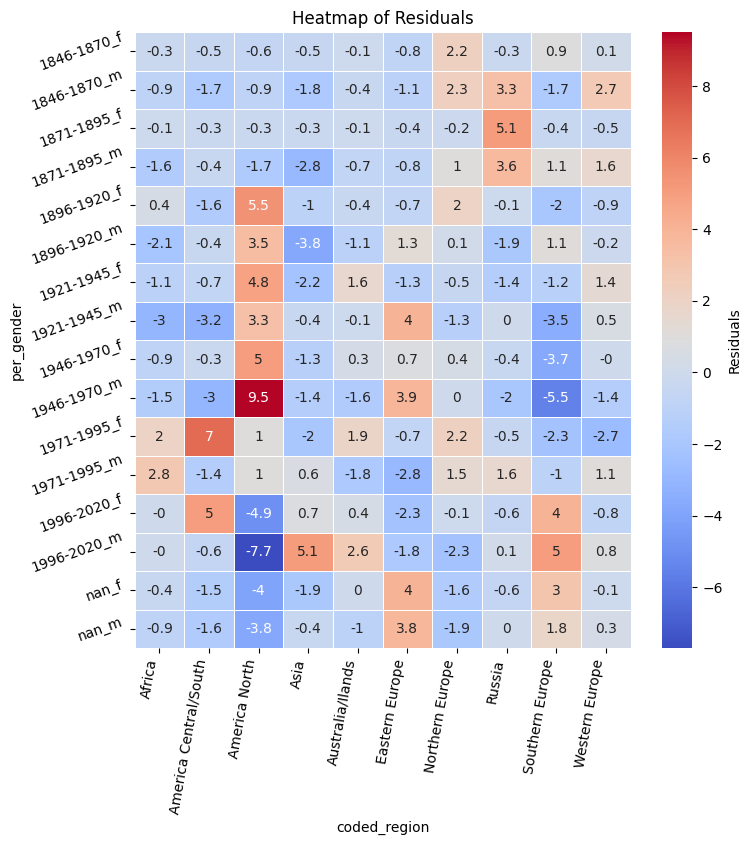

In [65]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

## Possible solution: restrain the table to the more recent values

In [66]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True).iloc[8:, :]
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1946-1970_f,2,13,39,10,1,36,10,5,5,49,170
1946-1970_m,15,56,202,75,1,240,51,23,70,264,997
1971-1995_f,26,122,92,53,7,139,54,25,82,186,786
1971-1995_m,91,233,339,281,7,507,175,124,389,916,3062
1996-2020_f,21,124,51,91,5,148,48,30,172,261,951
1996-2020_m,46,165,105,254,17,355,83,74,362,622,2083
nan_f,4,12,4,11,1,67,6,6,46,63,220
nan_m,3,12,5,18,0,67,5,8,40,67,225
All,211,790,998,841,42,1781,485,334,1272,2742,9496


In [67]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [68]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [69]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1946-1970_f,4.2,14.8,16.8,15.9,0.8,31.2,8.6,5.9,23.3,48.6
1946-1970_m,24.4,86.5,98.2,93.1,4.6,183.0,50.7,34.6,136.9,285.0
1971-1995_f,19.2,68.2,77.5,73.4,3.6,144.3,40.0,27.3,107.9,224.7
1971-1995_m,75.0,265.7,301.7,285.9,14.1,562.0,155.7,106.3,420.3,875.3
1996-2020_f,23.3,82.5,93.7,88.8,4.4,174.5,48.4,33.0,130.5,271.8
1996-2020_m,51.0,180.7,205.3,194.5,9.6,382.3,105.9,72.3,285.9,595.4
nan_f,5.4,19.1,21.7,20.5,1.0,40.4,11.2,7.6,30.2,62.9
nan_m,5.5,19.5,22.2,21.0,1.0,41.3,11.4,7.8,30.9,64.3


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [70]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 593.404242862666 , dof : 63
p-value : 2.6854666082351605e-87


In [71]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.09990107815891765


Comment: not very significant relationship, only some interesting observations on Southern Europe and Central/Southern America

In [72]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

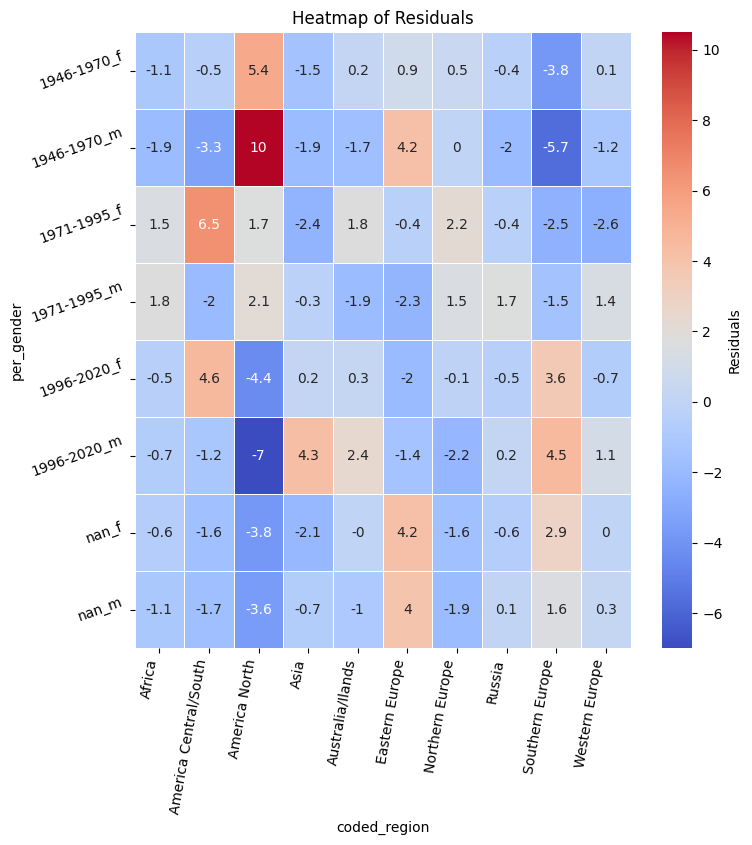

In [73]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

In [74]:
df_pg.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,1801-1810,23,Northern America,America North,1851,1846-1870,1846-1870_m
1,http://www.wikidata.org/entity/Q5400003,Adolphe Hugentobler,1810,male,Cortaillod,POINT (6.84793 46.94399),http://www.wikidata.org/entity/Q70308,1801-1810,22,Western Europe,Western Europe,1855,1846-1870,1846-1870_m
2,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,1801-1810,22,Western Europe,Western Europe,1846,1846-1870,1846-1870_m
3,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,1801-1810,22,Western Europe,Western Europe,1851,1846-1870,1846-1870_m
4,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1802,female,Norwich,POINT (1.292778 52.628611),http://www.wikidata.org/entity/Q130191,1801-1810,24,Northern Europe,Northern Europe,1847,1846-1870,1846-1870_f


In [75]:
dfs = df_pg[(df_pg.per_gender.isin(['2001-2025_f']))&(df_pg.coded_region.isin(['Southern Europe', 'America Central/South']))]
print(len(dfs))

0


In [76]:
dfs.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender


In [77]:
dfs[dfs['labelPer'].str.contains('Vaccaro', na=False)]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender


In [78]:
df_p[df_p['labelPer'].str.contains('Vaccaro', na=False)]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25
249,http://www.wikidata.org/entity/Q3856468,Michelangelo Vaccaro,1854,male,Casteltermini,POINT (13.645278 37.541667),http://www.wikidata.org/entity/Q431446,1851-1860,19,Southern Europe,Southern Europe,1899,1896-1920


[Luciana Vaccaro](https://fr.wikipedia.org/wiki/Luciana_Vaccaro) (Wikipedia)